# Linear & Polynomial Regression on Salary Data

This notebook demonstrates **Simple Linear Regression** and **Polynomial Regression** to predict salary based on years of experience.

---

## 1. Importing Libraries

We start by importing all necessary Python libraries for data manipulation, visualization, and machine learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

## 2. Loading & Exploring the Dataset

We load the **Salary** dataset and perform basic exploratory data analysis (EDA) to understand:
- Shape of the dataset
- Column names and data types
- Missing values
- Basic statistics
- Duplicate rows

In [3]:
df = pd.read_csv(r'F:\HUAWEL_AI\GitHub\Data_CSV\Salary.csv')

print("Dataset shape:", df.shape)

print("\nDataFrame Columns")
print(df.columns)

print("\nColumn information:")
print(df.info())

print("\nMissing values (Null):")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

print("\nDuplicated:")
print(df.duplicated().sum())

Dataset shape: (30, 3)

DataFrame Columns
Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes
None

Missing values (Null):
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

Basic statistics:
       Unnamed: 0  YearsExperience         Salary
count   30.000000        30.000000      30.000000
mean    14.500000         5.413333   76004.000000
std      8.803408         2.837888   27414.429785
min      0.000000         1.200000   37732.000000
25%      7.250000         3.300000   56721.750000
50%     14.500000         4.800000   65238.000000
75%     2

## 3. Data Cleaning

We drop any rows with missing values using `dropna()` and preview the first few rows with `df.head()`.

In [4]:
df.dropna(inplace = True)
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


## 4. Defining Features and Target

We separate the dataset into:
- **`x`** — Input feature: `YearsExperience`
- **`y`** — Target variable: `Salary`

In [5]:
x = df.drop(['Salary','Unnamed: 0'],axis=1)
y=df['Salary']

## 5. Training the Linear Regression Model

We instantiate and fit a `LinearRegression` model from scikit-learn on the full dataset.

In [6]:
lin_model = LinearRegression()
lin_model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6. Generating Predictions (Linear)

We use the trained linear model to generate predictions for all training samples.

In [7]:
pred = lin_model.predict(x)

## 7. Visualizing Linear Regression

We plot the original data points as a scatter plot (blue) and overlay the linear regression line (green).

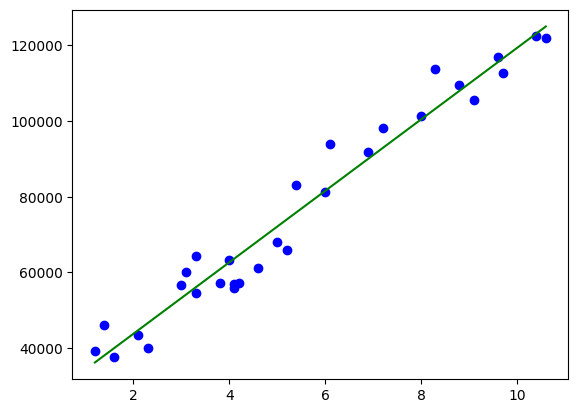

In [8]:
plt.scatter(x,y, c='blue')
plt.plot(x,pred,color='g')
plt.show()

## 8. Predicting a Single Value

We predict the expected salary for an employee with **5 years of experience** using the linear model.

In [9]:
pred_val = lin_model.predict(np.array([[5]]))
pred_val

c:\Users\Yousef_Osama\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([72098.0155738])

## 9. Polynomial Feature Transformation

To capture non-linear patterns, we transform the input features using `PolynomialFeatures` with **degree = 5**.

In [10]:
poly_reg = PolynomialFeatures(degree = 5 )
x_poly = poly_reg.fit_transform(x)


## 10. Training the Polynomial Regression Model

We fit a new `LinearRegression` model on the polynomial-transformed features.

In [11]:
poly_reg_model = LinearRegression()
poly_reg_model.fit(x_poly,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 11. Generating Predictions (Polynomial)

We use the polynomial regression model to generate predictions on the transformed training data.

In [12]:
poly_pred = poly_reg_model.predict(x_poly)

## 12. Visualizing Polynomial Regression

We plot the original data points (blue) and overlay the polynomial regression curve (green) to compare its fit against the linear model.

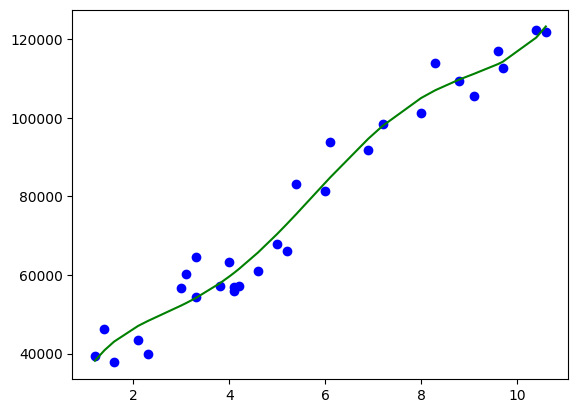

In [13]:
plt.scatter(x,y, c='blue')
plt.plot(x,poly_pred,color='g')
plt.show()